# 04 Audio Emotion Recognition
**Project:** MoodSyncAI — Multi-Modal Sentiment & Emotion Analyser  
**Module:** Data Analytics-3  

## Model Pipeline
```
Audio Input (.wav / .mp3 / .flac)
         │
         ▼
Resampling → 16 kHz mono
         │
         ▼
Feature Extraction  ← MFCC×3 (120) + Mel-Spec (64) + Chroma (12) + ZCR (1) + RMS (1) = 198 dims
         │
         ▼
1-D CNN (4 layers) + BiLSTM (2 layers)
         │
         ▼
7-Class Emotion Probabilities
  ┌──────┬─────────┬──────┬───────┬─────────┬──────┬──────────┐
  │angry │ disgust │ fear │ happy │ neutral │  sad │ surprise │
  │ 0.XX │  0.XX   │ 0.XX │ 0.XX  │  0.XX   │ 0.XX │  0.XX   │
  └──────┴─────────┴──────┴───────┴─────────┴──────┴──────────┘
         │
         ▼
Top Emotion + Confidence  (e.g. "happy  87.3%")
         │
         ▼
Polarity Bridge (for audio-text fusion)
  happy / surprise  →  positive
  neutral           →  neutral
  angry / disgust / fear / sad  →  negative
```

> **Key design principle:** The model always outputs **all 7 emotion probabilities**.
> The polarity bridge is a secondary, derived field for the fusion layer —
> the raw 7-class distribution is the primary output.

## Objectives
1. Load **RAVDESS** + **CREMA-D** from Hugging Face  
2. Explore dataset distribution and audio characteristics  
3. Extract a 198-dim feature vector per clip (MFCC×3, Mel, Chroma, ZCR, RMS)  
4. Augment training audio (noise, pitch-shift, time-stretch, gain)  
5. Build a **1-D CNN → BiLSTM → Dense** classifier  
6. Train with cosine-annealing LR and early stopping  
7. Plot training accuracy / validation accuracy / loss / LR schedule  
8. Confusion matrix + per-class classification report  
9. Define `predict_audio(path)` → **returns full 7-class probability distribution**  
10. Visualise all 7 emotion probabilities for any input clip  
11. Save model + label encoder to `saved_models/audio_emotion/`  

---

## 0  Environment Setup & Imports

In [4]:
!pip install librosa

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 99.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 105.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 87.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [librosa]m8/9 [librosa]]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [5]:
import os, sys, time, warnings, json, random
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import librosa
import librosa.display
import soundfile as sf

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from datasets import load_dataset
import pickle

# ── reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── constants ─────────────────────────────────────────────────────────────────
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_RATE  = 16_000          # 16 kHz — standard for speech
MAX_DURATION = 3.0             # seconds  (clips trimmed / zero-padded)
N_MFCC       = 40
N_MELS       = 64
HOP_LENGTH   = 512
N_FFT        = 2048
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-3
SAVE_DIR     = Path("saved_models/audio_emotion")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── 7 emotion classes (mirrors visual ResNet50V2 model) ───────────────────────
EMOTION_CLASSES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
NUM_CLASSES     = len(EMOTION_CLASSES)

# ── polarity bridge (secondary — used by fusion layer only) ───────────────────
AUDIO_TO_POLARITY = {
    "happy":    "positive",
    "surprise": "positive",
    "neutral":  "neutral",
    "angry":    "negative",
    "disgust":  "negative",
    "fear":     "negative",
    "sad":      "negative",
}

CONF_THRESHOLD = 0.50   # minimum confidence for HARD_MISMATCH in fusion

# ── per-emotion colours (matches all other notebooks) ─────────────────────────
EMOTION_COLOURS = {
    "angry":    "#EF5350",
    "disgust":  "#AB47BC",
    "fear":     "#FF7043",
    "happy":    "#4CAF50",
    "neutral":  "#FFA726",
    "sad":      "#42A5F5",
    "surprise": "#81C784",
}

# ── dark matplotlib theme (matches notebooks 1-3) ─────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#111111", "axes.facecolor": "#1c1c1c",
    "axes.edgecolor":   "#333333", "axes.labelcolor": "#cccccc",
    "xtick.color":      "#aaaaaa", "ytick.color":     "#aaaaaa",
    "text.color":       "#e0e0e0", "grid.color":      "#2a2a2a",
    "grid.linestyle":   "--",      "font.family":     "DejaVu Sans",
})

print(f"Python  {sys.version.split()[0]}")
print(f"PyTorch {torch.__version__}")
print(f"librosa {librosa.__version__}")
print(f"Device  {DEVICE}")
print()
print("Emotion classes (primary output):")
for i, emo in enumerate(EMOTION_CLASSES):
    print(f"  {i} → {emo:10s}  polarity: {AUDIO_TO_POLARITY[emo]}")


Python  3.11.13
PyTorch 2.9.1+cu128
librosa 0.11.0
Device  cuda

Emotion classes (primary output):
  0 → angry       polarity: negative
  1 → disgust     polarity: negative
  2 → fear        polarity: negative
  3 → happy       polarity: positive
  4 → neutral     polarity: neutral
  5 → sad         polarity: negative
  6 → surprise    polarity: positive


## 1  Dataset — RAVDESS + CREMA-D

| Dataset | Actors | Clips | Emotions |
|---------|--------|-------|----------|
| **RAVDESS** | 24 professional actors | ~1,440 speech clips | 8 (neutral/calm merged → 7) |
| **CREMA-D** | 91 actors | 7,442 clips | 6 (no surprise) |

Both loaded from Hugging Face Hub; merged into a unified DataFrame.

> **Why these two?** RAVDESS is the gold-standard acted-speech corpus; CREMA-D adds racial/age diversity and ~5× more samples, reducing demographic bias.

In [8]:
from datasets import load_dataset, concatenate_datasets

print("Loading RAVDESS from Hugging Face (Parquet, all folds)…")
folds = [load_dataset("confit/ravdess-parquet", fold, split="train")
         for fold in ["fold1", "fold2", "fold3", "fold4", "fold5"]]
ravdess_ds = concatenate_datasets(folds)
print(f"RAVDESS rows     : {len(ravdess_ds)}")
print(f"RAVDESS features : {list(ravdess_ds.features.keys())}")

Loading RAVDESS from Hugging Face (Parquet, all folds)…


fold1/train-00000-of-00002.parquet:   0%|          | 0.00/260M [00:00<?, ?B/s]

fold1/train-00001-of-00002.parquet:   0%|          | 0.00/260M [00:00<?, ?B/s]

fold1/test-00000-of-00001.parquet:   0%|          | 0.00/131M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2280 [00:00<?, ? examples/s]

...

fold5/train-00001-of-00002.parquet:   0%|          | 0.00/274M [00:00<?, ?B/s]

fold5/test-00000-of-00001.parquet:   0%|          | 0.00/102M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2400 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/480 [00:00<?, ? examples/s]

RAVDESS rows     : 11520
RAVDESS features : ['file', 'audio', 'emotion', 'label']


In [11]:
!pip install -q "datasets==3.6.0"


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [14]:
import io
import soundfile as sf
from datasets import Audio

# Already done above: ravdess_ds = ravdess_ds.cast_column("audio", Audio(decode=False))

RAVDESS_MAP = {
    "neutral":   "neutral",
    "calm":      "neutral",
    "happy":     "happy",
    "sad":       "sad",
    "angry":     "angry",
    "fearful":   "fear",
    "disgust":   "disgust",
    "surprised": "surprise",
}

ravdess_records = []
for sample in ravdess_ds:
    try:
        audio_info = sample["audio"]

        # Try bytes first, fall back to path
        if audio_info["bytes"] is not None:
            arr, sr = sf.read(io.BytesIO(audio_info["bytes"]), dtype="float32", always_2d=False)
        else:
            arr, sr = sf.read(audio_info["path"], dtype="float32", always_2d=False)

        label = RAVDESS_MAP.get(sample["emotion"])   # use "emotion" string column
        if label and label in EMOTION_CLASSES:
            ravdess_records.append({"audio": arr, "sr": sr, "label": label, "source": "ravdess"})
    except Exception as e:
        pass

print(f"RAVDESS parsed: {len(ravdess_records)} records")
import pandas as pd
pd.Series([r["label"] for r in ravdess_records]).value_counts()

RAVDESS parsed: 11520 records


neutral     2304
fear        1536
surprise    1536
angry       1536
disgust     1536
sad         1536
happy       1536
Name: count, dtype: int64

In [16]:
from datasets import Audio

print("Loading CREMA-D from Hugging Face…")
cremad_ds = load_dataset("cfahlgren1/crema-d", split="train")
cremad_ds = cremad_ds.cast_column("audio", Audio(decode=False))   # avoid torchcodec
print(f"CREMA-D  rows: {len(cremad_ds)}")
print(f"CREMA-D  features: {list(cremad_ds.features.keys())}")
print(f"CREMA-D  first sample: { {k:v for k,v in cremad_ds[0].items() if k != 'audio'} }")

Loading CREMA-D from Hugging Face…


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/160M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/148M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/146M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/152M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7442 [00:00<?, ? examples/s]

CREMA-D  rows: 7442
CREMA-D  features: ['audio', 'actor_id', 'sentence_code', 'sentence', 'emotion_code', 'emotion_intensity', 'intensity_code', 'label', 'source_file']
CREMA-D  first sample: {'actor_id': '1001', 'sentence_code': 'DFA', 'sentence': "Don't forget a jacket", 'emotion_code': 'ANG', 'emotion_intensity': 'Unspecified', 'intensity_code': 'XX', 'label': 0, 'source_file': '1001_DFA_ANG_XX.wav'}


In [18]:
sample = cremad_ds[0]
print("Keys:", list(sample.keys()))
for k, v in sample.items():
    if k != "audio":
        print(f"  {k}: {repr(v)}")
print("Audio keys:", list(sample["audio"].keys()))
print("Audio bytes is None:", sample["audio"]["bytes"] is None)
print("Audio path:", sample["audio"].get("path"))

Keys: ['audio', 'actor_id', 'sentence_code', 'sentence', 'emotion_code', 'emotion_intensity', 'intensity_code', 'label', 'source_file']
  actor_id: '1001'
  sentence_code: 'DFA'
  sentence: "Don't forget a jacket"
  emotion_code: 'ANG'
  emotion_intensity: 'Unspecified'
  intensity_code: 'XX'
  label: 0
  source_file: '1001_DFA_ANG_XX.wav'
Audio keys: ['bytes', 'path']
Audio bytes is None: False
Audio path: 1001_DFA_ANG_XX.wav


In [19]:
CREMAD_MAP = {
    "anger":   "angry",
    "disgust": "disgust",
    "fear":    "fear",
    "happy":   "happy",
    "neutral": "neutral",
    "sad":     "sad",
}

cremad_records = []
for sample in cremad_ds:
    try:
        audio_info = sample["audio"]
        if audio_info["bytes"] is not None:
            arr, sr = sf.read(io.BytesIO(audio_info["bytes"]), dtype="float32", always_2d=False)
        else:
            arr, sr = sf.read(audio_info["path"], dtype="float32", always_2d=False)

        # Try all possible label column names
        raw_label = (sample.get("classname") or sample.get("label") or
                     sample.get("emotion") or sample.get("emotion_label") or "")
        if isinstance(raw_label, int):
            # integer label — map index to string
            label_names = ["anger","disgust","fear","happy","neutral","sad"]
            raw_label = label_names[raw_label] if raw_label < len(label_names) else ""
        label = CREMAD_MAP.get(str(raw_label).lower().strip())
        if label and label in EMOTION_CLASSES:
            cremad_records.append({"audio": arr, "sr": sr, "label": label, "source": "cremad"})
    except Exception as e:
        print(f"Error: {e}"); break   # show first error instead of silently passing

print(f"CREMA-D parsed: {len(cremad_records)} records")
pd.Series([r["label"] for r in cremad_records]).value_counts()

CREMA-D parsed: 6171 records


disgust    1271
fear       1271
happy      1271
sad        1271
neutral    1087
Name: count, dtype: int64

In [20]:
all_records = ravdess_records + cremad_records
df = pd.DataFrame([{"label": r["label"], "source": r["source"]} for r in all_records])
df.index = range(len(df))

print(f"Total samples : {len(df)}")
print("\nLabel distribution (all 7 emotions):")
dist = df["label"].value_counts().reindex(EMOTION_CLASSES, fill_value=0)
for emo, cnt in dist.items():
    bar = "█" * (cnt // 50)
    print(f"  {emo:10s}: {cnt:5d}  {bar}")

Total samples : 17691

Label distribution (all 7 emotions):
  angry     :  1536  ██████████████████████████████
  disgust   :  2807  ████████████████████████████████████████████████████████
  fear      :  2807  ████████████████████████████████████████████████████████
  happy     :  2807  ████████████████████████████████████████████████████████
  neutral   :  3391  ███████████████████████████████████████████████████████████████████
  sad       :  2807  ████████████████████████████████████████████████████████
  surprise  :  1536  ██████████████████████████████


## 2  Exploratory Data Analysis

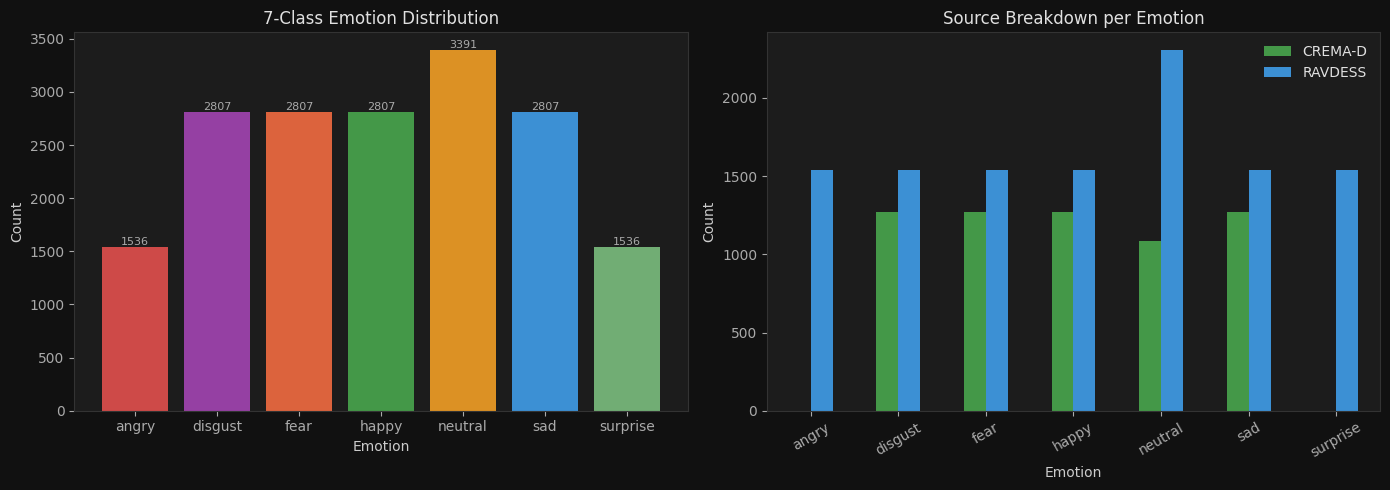

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df["label"].value_counts().reindex(EMOTION_CLASSES, fill_value=0)
bars = axes[0].bar(counts.index, counts.values,
                   color=[EMOTION_COLOURS[e] for e in counts.index], alpha=0.85, edgecolor="none")
axes[0].set_title("7-Class Emotion Distribution", fontsize=12, color="#e0e0e0")
axes[0].set_xlabel("Emotion"); axes[0].set_ylabel("Count")
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 20, str(v),
                 ha="center", fontsize=8, color="#aaaaaa")

src = df.groupby(["label","source"]).size().unstack(fill_value=0).reindex(EMOTION_CLASSES, fill_value=0)
src.plot(kind="bar", ax=axes[1], color=["#4CAF50","#42A5F5"], alpha=0.85, edgecolor="none")
axes[1].set_title("Source Breakdown per Emotion", fontsize=12, color="#e0e0e0")
axes[1].set_xlabel("Emotion"); axes[1].set_ylabel("Count")
axes[1].legend(["CREMA-D","RAVDESS"], framealpha=0)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("audio_class_distribution.png", dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show()

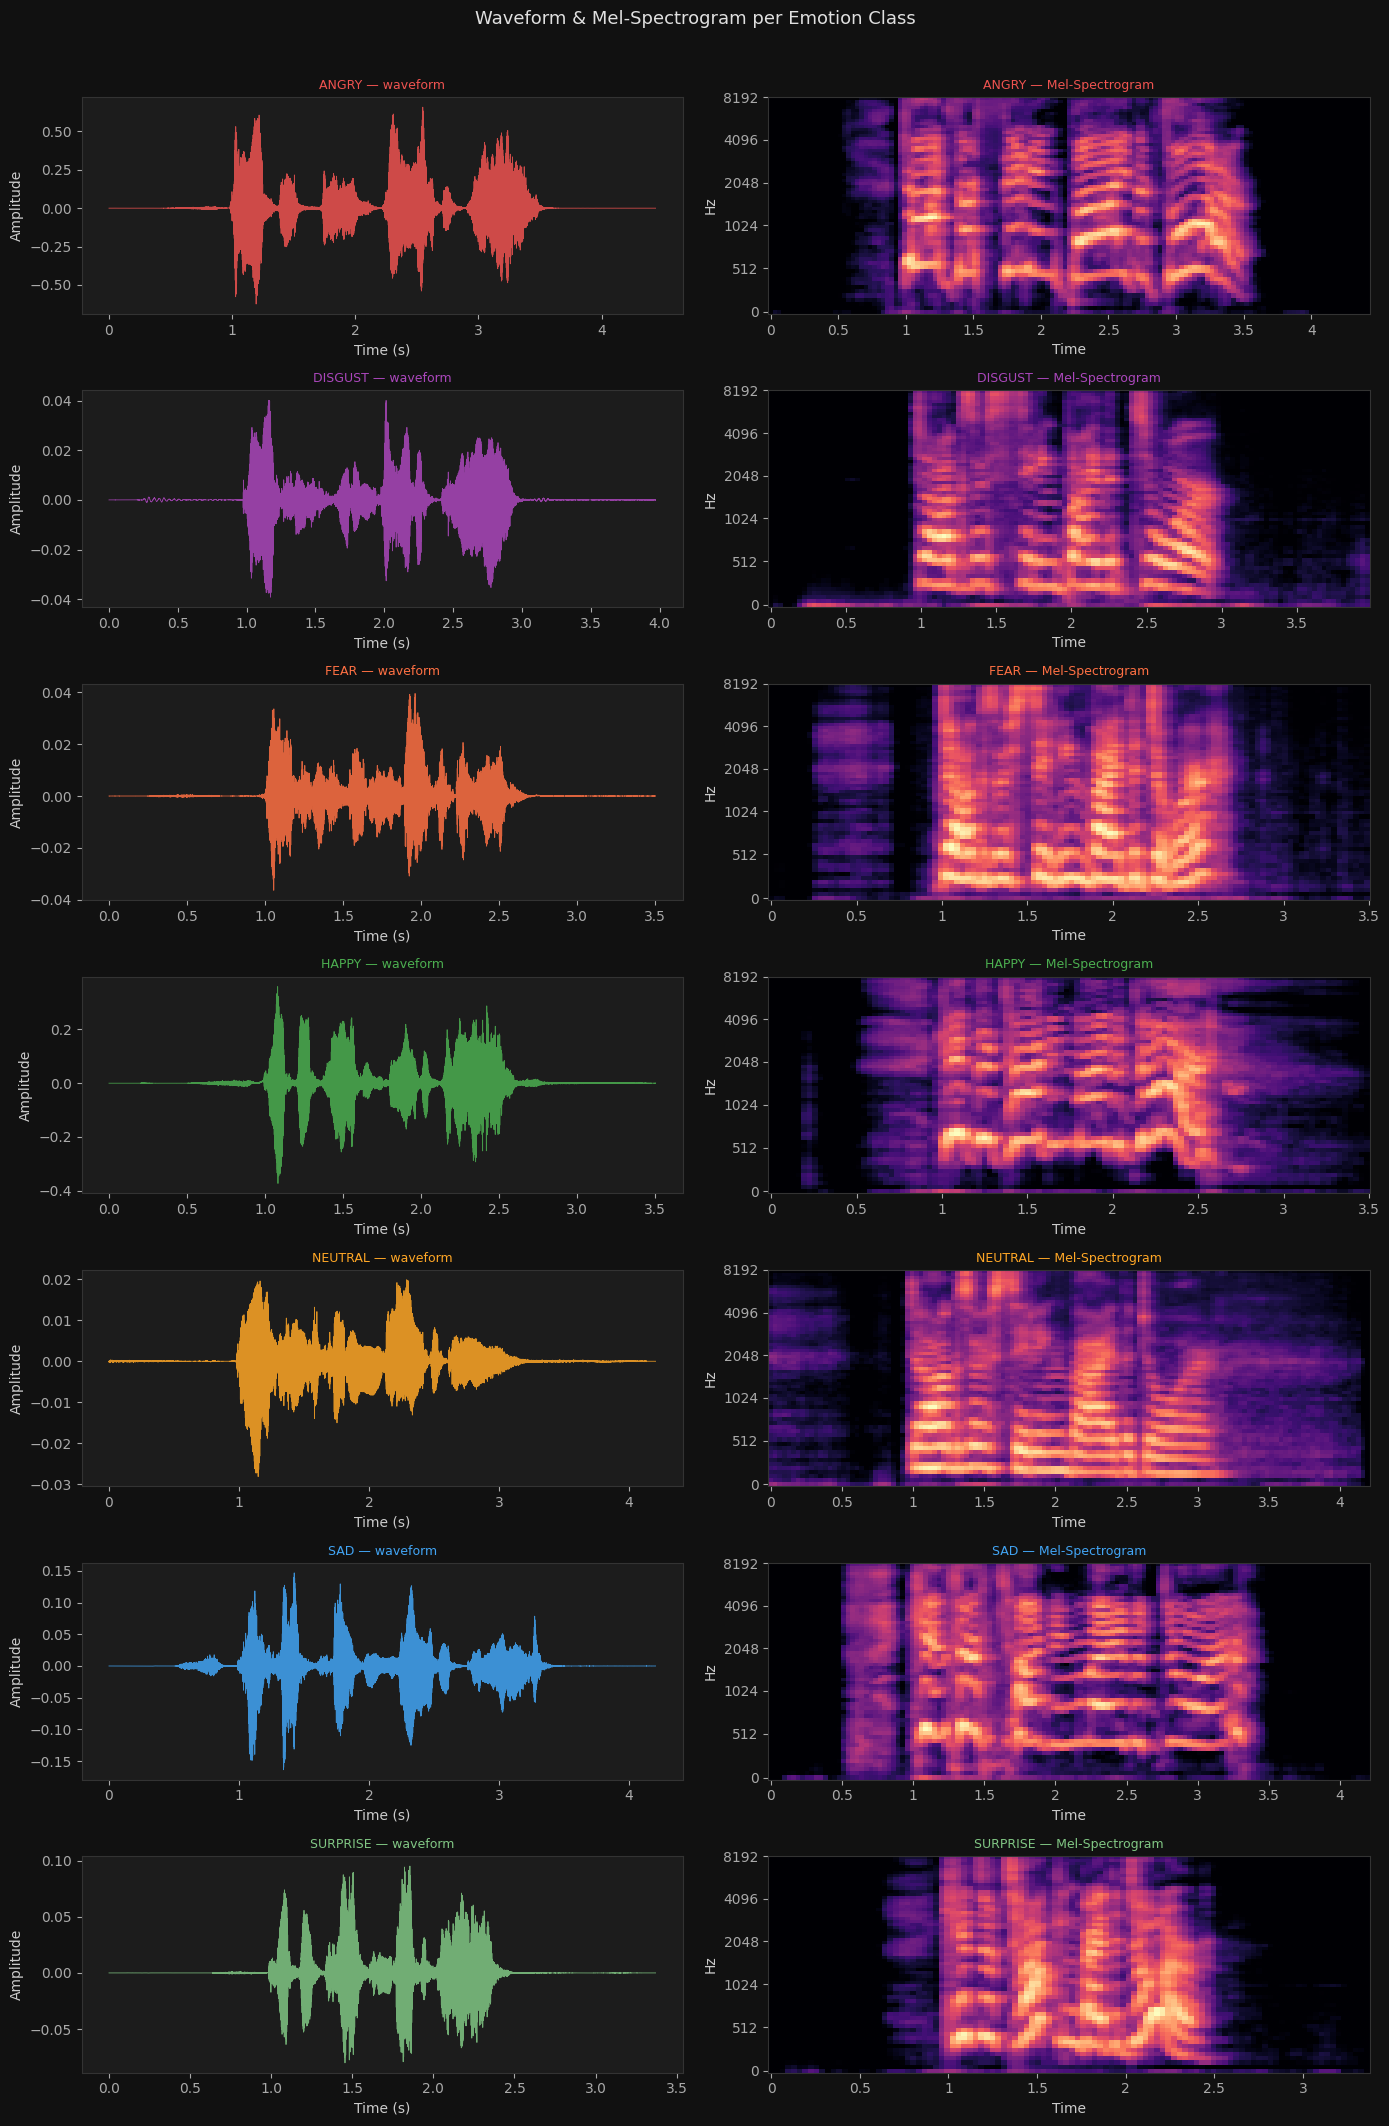

In [22]:
fig, axes = plt.subplots(len(EMOTION_CLASSES), 2, figsize=(14, 3 * len(EMOTION_CLASSES)))

for i, emotion in enumerate(EMOTION_CLASSES):
    idx  = df[df["label"] == emotion].index[0]
    rec  = all_records[idx]
    arr  = librosa.resample(rec["audio"], orig_sr=rec["sr"], target_sr=SAMPLE_RATE)

    axes[i, 0].plot(np.linspace(0, len(arr)/SAMPLE_RATE, len(arr)), arr,
                    color=EMOTION_COLOURS[emotion], linewidth=0.6, alpha=0.85)
    axes[i, 0].set_title(f"{emotion.upper()} — waveform", fontsize=9, color=EMOTION_COLOURS[emotion])
    axes[i, 0].set_xlabel("Time (s)"); axes[i, 0].set_ylabel("Amplitude")

    S    = librosa.feature.melspectrogram(y=arr, sr=SAMPLE_RATE, n_mels=N_MELS,
                                           n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis="time", y_axis="mel", ax=axes[i, 1], cmap="magma")
    axes[i, 1].set_title(f"{emotion.upper()} — Mel-Spectrogram", fontsize=9, color=EMOTION_COLOURS[emotion])

plt.suptitle("Waveform & Mel-Spectrogram per Emotion Class", fontsize=13, color="#e0e0e0", y=1.01)
plt.tight_layout()
plt.savefig("audio_waveform_mel.png", dpi=120, bbox_inches="tight", facecolor="#111111")
plt.show()

## 3  Preprocessing & Feature Extraction

Each clip → fixed-length feature tensor of shape `(198, time_frames)`:

| Feature | Dim | Description |
|---------|-----|-------------|
| MFCC | 40 | Mel-frequency cepstral coefficients |
| Δ-MFCC | 40 | First-order delta (temporal dynamics) |
| ΔΔ-MFCC | 40 | Second-order delta (acceleration) |
| Mel-spectrogram | 64 | Log-compressed mel energy |
| Chroma | 12 | Pitch-class energy |
| ZCR | 1 | Zero-crossing rate |
| RMS | 1 | Root-mean-square energy |
| **Total** | **198** | |

All clips resampled → 16 kHz, padded/trimmed to `MAX_DURATION × SAMPLE_RATE = 48,000` samples.

In [23]:
MAX_SAMPLES = int(MAX_DURATION * SAMPLE_RATE)   # 48 000

def pad_or_trim(audio: np.ndarray, target: int = MAX_SAMPLES) -> np.ndarray:
    if len(audio) >= target:
        return audio[:target]
    return np.pad(audio, (0, target - len(audio)), mode="constant")


def extract_features(audio: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    """Return (198, time_frames) float32 feature array."""
    audio  = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
    audio  = pad_or_trim(audio)

    mfcc   = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
                                   n_fft=N_FFT, hop_length=HOP_LENGTH)
    d_mfcc = librosa.feature.delta(mfcc)
    dd_mfcc= librosa.feature.delta(mfcc, order=2)
    mel    = librosa.power_to_db(
                librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE,
                                               n_mels=N_MELS, n_fft=N_FFT,
                                               hop_length=HOP_LENGTH), ref=np.max)
    chroma = librosa.feature.chroma_stft(y=audio, sr=SAMPLE_RATE,
                                          n_fft=N_FFT, hop_length=HOP_LENGTH)
    zcr    = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)
    rms    = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)

    def norm(x):
        mu  = x.mean(axis=1, keepdims=True)
        std = x.std(axis=1,  keepdims=True) + 1e-8
        return (x - mu) / std

    features = np.concatenate(
        [norm(mfcc), norm(d_mfcc), norm(dd_mfcc),
         norm(mel),  norm(chroma), norm(zcr), norm(rms)], axis=0)
    return features.astype(np.float32)


# smoke test
feat = extract_features(all_records[0]["audio"], all_records[0]["sr"])
print(f"Feature shape : {feat.shape}   → (feature_dim=198, time_frames)")
print(f"Feature dtype : {feat.dtype}")

Feature shape : (198, 94)   → (feature_dim=198, time_frames)
Feature dtype : float32


## 4  Audio Augmentation (training only)

| Technique | Parameter | Effect |
|-----------|-----------|--------|
| Additive Gaussian noise | σ=0.005 | Mic noise |
| Pitch shift | ±2 semitones | Speaker pitch variation |
| Time stretch | rate ∈ [0.9, 1.1] | Speed variation |
| Random gain | ×[0.8, 1.2] | Volume variation |

Each applied with probability **p = 0.5** independently.

In [24]:
def augment_audio(audio: np.ndarray, sr: int = SAMPLE_RATE, p: float = 0.5) -> np.ndarray:
    if random.random() < p:
        audio = audio + 0.005 * np.random.randn(*audio.shape).astype(np.float32)
    if random.random() < p:
        audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=random.uniform(-2, 2))
    if random.random() < p:
        audio = librosa.effects.time_stretch(audio, rate=random.uniform(0.9, 1.1))
    if random.random() < p:
        audio = audio * random.uniform(0.8, 1.2)
    return audio.astype(np.float32)

print("augment_audio() defined — applied on-the-fly during training.")

augment_audio() defined — applied on-the-fly during training.


## 5  Full Feature Extraction Pass

In [25]:
print(f"Extracting features for {len(all_records)} clips…")
t0 = time.time()

X_list, y_list, failed = [], [], 0
for rec in all_records:
    try:
        X_list.append(extract_features(rec["audio"], rec["sr"]))
        y_list.append(rec["label"])
    except Exception:
        failed += 1

X     = np.stack(X_list)          # (N, 198, time_frames)
y_raw = np.array(y_list)

print(f"Done in {time.time()-t0:.1f}s  |  failed: {failed}")
print(f"X shape : {X.shape}  →  (N_samples, feature_dim=198, time_frames)")
print(f"Labels  : {np.unique(y_raw)}")

Extracting features for 17691 clips…
Done in 266.7s  |  failed: 40
X shape : (17651, 198, 94)  →  (N_samples, feature_dim=198, time_frames)
Labels  : ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']


In [26]:
le = LabelEncoder()
le.fit(EMOTION_CLASSES)
y = le.transform(y_raw)

print("Label encoder mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx} → {cls}")

with open(SAVE_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print(f"\nSaved label encoder → {SAVE_DIR / 'label_encoder.pkl'}")

Label encoder mapping:
  0 → angry
  1 → disgust
  2 → fear
  3 → happy
  4 → neutral
  5 → sad
  6 → surprise

Saved label encoder → saved_models/audio_emotion/label_encoder.pkl


## 6  Train / Validation / Test Split (stratified)

- **Train**: 70%  |  **Validation**: 15%  |  **Test**: 15%

In [27]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.176, stratify=y_tv, random_state=SEED)

print(f"Train : {X_train.shape[0]:5d}  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val   : {X_val.shape[0]:5d}  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]:5d}  ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nStratification check:")
for name, sy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    u, c = np.unique(sy, return_counts=True)
    print(f"  {name}: { {le.classes_[i]:c for i,c in zip(u,c)} }")


Train : 12362  (70.0%)
Val   :  2641  (15.0%)
Test  :  2648  (15.0%)

Stratification check:
  Train: {np.str_('angry'): np.int64(1075), np.str_('disgust'): np.int64(1966), np.str_('fear'): np.int64(1960), np.str_('happy'): np.int64(1960), np.str_('neutral'): np.int64(2364), np.str_('sad'): np.int64(1966), np.str_('surprise'): np.int64(1071)}
  Val: {np.str_('angry'): np.int64(230), np.str_('disgust'): np.int64(420), np.str_('fear'): np.int64(419), np.str_('happy'): np.int64(419), np.str_('neutral'): np.int64(505), np.str_('sad'): np.int64(420), np.str_('surprise'): np.int64(228)}
  Test: {np.str_('angry'): np.int64(231), np.str_('disgust'): np.int64(421), np.str_('fear'): np.int64(420), np.str_('happy'): np.int64(420), np.str_('neutral'): np.int64(506), np.str_('sad'): np.int64(421), np.str_('surprise'): np.int64(229)}


## 7  PyTorch Dataset & DataLoader

In [28]:
class AudioEmotionDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_ds = AudioEmotionDataset(X_train, y_train)
val_ds   = AudioEmotionDataset(X_val,   y_val)
test_ds  = AudioEmotionDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

xb, yb = next(iter(train_loader))
print(f"Batch X : {xb.shape}  →  (batch, feature_dim=198, time_frames)")
print(f"Batch y : {yb.shape}")

Batch X : torch.Size([32, 198, 94])  →  (batch, feature_dim=198, time_frames)
Batch y : torch.Size([32])


## 8  Model Architecture — 1-D CNN + BiLSTM → 7 Classes

```
Input  (batch, 198, T)
  │
  ├─ Conv1d(198→256, k=3) → BN → ReLU → Dropout(0.25)
  ├─ Conv1d(256→256, k=3) → BN → ReLU → MaxPool1d(2) → Dropout(0.25)
  ├─ Conv1d(256→512, k=3) → BN → ReLU → Dropout(0.25)
  ├─ Conv1d(512→512, k=3) → BN → ReLU → MaxPool1d(2) → Dropout(0.25)
  │
  ▼
BiLSTM(hidden=256, layers=2)  → last time-step  →  (batch, 512)
  │
FC(512→256) → ReLU → Dropout(0.4)
FC(256→7)
  │
  ▼ (7 raw logits — softmax applied at inference to get probabilities)
```

In [29]:
class AudioEmotionNet(nn.Module):
    def __init__(self, in_channels: int = 198, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.25),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.25),
            nn.Conv1d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.25),
            nn.Conv1d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.25),
        )
        self.lstm = nn.LSTM(input_size=512, hidden_size=256, num_layers=2,
                            batch_first=True, bidirectional=True, dropout=0.3)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x          = self.cnn(x)                  # (B, 512, T//4)
        x          = x.permute(0, 2, 1)           # (B, T//4, 512)
        out, _     = self.lstm(x)
        x          = out[:, -1, :]                # last time-step  (B, 512)
        return self.classifier(x)                 # (B, 7) — raw logits


model = AudioEmotionNet().to(DEVICE)
dummy = torch.zeros(2, 198, X_train.shape[2]).to(DEVICE)
out   = model(dummy)
print(f"Output shape   : {out.shape}   →  (batch=2, num_classes=7)")
print(f"Total params   : {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable      : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Output shape   : torch.Size([2, 7])   →  (batch=2, num_classes=7)
Total params   : 4,819,975
Trainable      : 4,819,975


## 9  Training Loop

- **Optimiser**: Adam (lr=1e-3, weight_decay=1e-4)  
- **Scheduler**: CosineAnnealingLR (T_max=50, eta_min=1e-6)  
- **Loss**: CrossEntropyLoss with per-class weights (handles imbalance)  
- **Early stopping**: patience=10 on validation accuracy

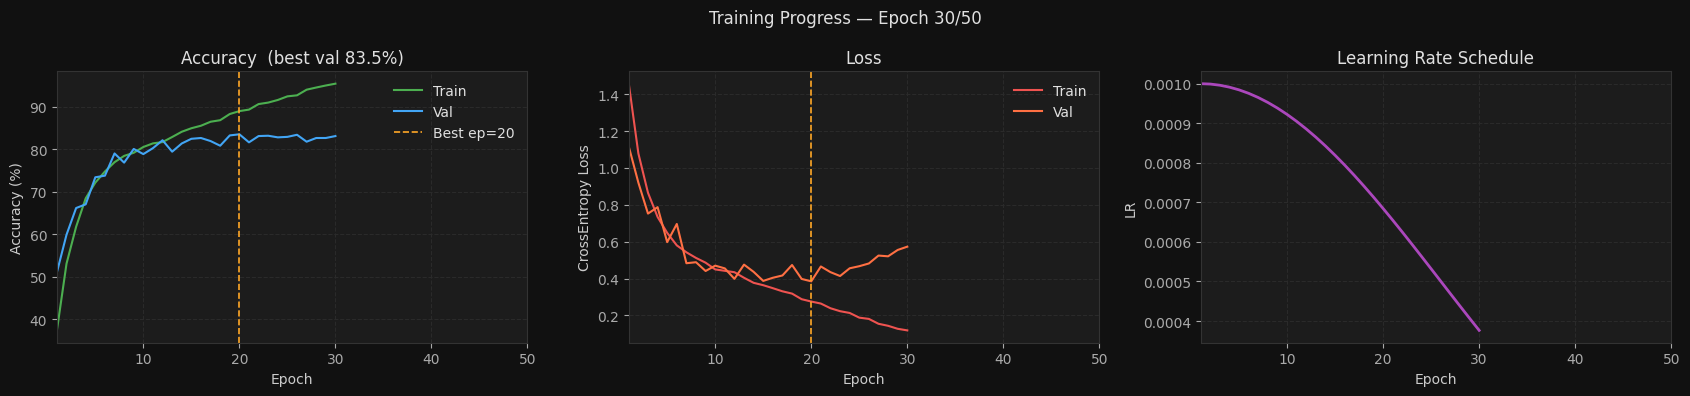

Early stopping @ epoch 30  (best=83.49% @ epoch 20)

Best validation accuracy: 83.49%  at epoch 20


In [30]:
from tqdm.auto import tqdm
from IPython.display import clear_output

class_counts  = np.bincount(y_train, minlength=NUM_CLASSES).astype(float)
class_weights = torch.tensor(class_counts.sum() / (NUM_CLASSES * class_counts),
                              dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if train: optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total

def plot_live(history, best_epoch, best_val_acc, current_epoch, total_epochs):
    ep = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    # Accuracy
    axes[0].plot(ep, [a*100 for a in history["train_acc"]], color="#4CAF50", label="Train")
    axes[0].plot(ep, [a*100 for a in history["val_acc"]],   color="#42A5F5", label="Val")
    if best_epoch: axes[0].axvline(best_epoch, color="#FFA726", linestyle="--", linewidth=1.2, label=f"Best ep={best_epoch}")
    axes[0].set_title(f"Accuracy  (best val {best_val_acc*100:.1f}%)", color="#e0e0e0")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
    axes[0].set_xlim(1, total_epochs); axes[0].legend(framealpha=0); axes[0].grid(True)

    # Loss
    axes[1].plot(ep, history["train_loss"], color="#EF5350", label="Train")
    axes[1].plot(ep, history["val_loss"],   color="#FF7043", label="Val")
    if best_epoch: axes[1].axvline(best_epoch, color="#FFA726", linestyle="--", linewidth=1.2)
    axes[1].set_title("Loss", color="#e0e0e0")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("CrossEntropy Loss")
    axes[1].set_xlim(1, total_epochs); axes[1].legend(framealpha=0); axes[1].grid(True)

    # LR
    axes[2].plot(ep, history["lr"], color="#AB47BC", linewidth=2)
    axes[2].set_title("Learning Rate Schedule", color="#e0e0e0")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
    axes[2].set_xlim(1, total_epochs); axes[2].grid(True)

    plt.suptitle(f"Training Progress — Epoch {current_epoch}/{total_epochs}", fontsize=12, color="#e0e0e0")
    plt.tight_layout()
    plt.show()

history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "lr":[]}
best_val_acc, patience_cnt, best_epoch = 0.0, 0, 0
PATIENCE = 10

epoch_bar = tqdm(range(1, EPOCHS + 1), desc="Training", unit="epoch",
                 colour="#42A5F5",
                 bar_format="{l_bar}{bar:35}{r_bar}")

for epoch in epoch_bar:
    t_loss, t_acc = run_epoch(train_loader, train=True)
    v_loss, v_acc = run_epoch(val_loader,   train=False)
    cur_lr        = optimizer.param_groups[0]["lr"]
    scheduler.step()

    history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc);   history["val_acc"].append(v_acc)
    history["lr"].append(cur_lr)

    flag = ""
    if v_acc > best_val_acc:
        best_val_acc = v_acc; best_epoch = epoch
        torch.save(model.state_dict(), SAVE_DIR / "best_audio_model.pt")
        flag = "✓ saved"; patience_cnt = 0
    else:
        patience_cnt += 1

    # update tqdm postfix with live metrics
    epoch_bar.set_postfix({
        "t_loss": f"{t_loss:.4f}",
        "v_loss": f"{v_loss:.4f}",
        "t_acc":  f"{t_acc*100:.1f}%",
        "v_acc":  f"{v_acc*100:.1f}%",
        "best":   f"{best_val_acc*100:.1f}%",
        "flag":   flag,
    })

    # redraw live chart every epoch
    clear_output(wait=True)
    plot_live(history, best_epoch, best_val_acc, epoch, EPOCHS)

    if patience_cnt >= PATIENCE:
        print(f"Early stopping @ epoch {epoch}  (best={best_val_acc*100:.2f}% @ epoch {best_epoch})")
        break

print(f"\nBest validation accuracy: {best_val_acc*100:.2f}%  at epoch {best_epoch}")

## 10  Training Curves

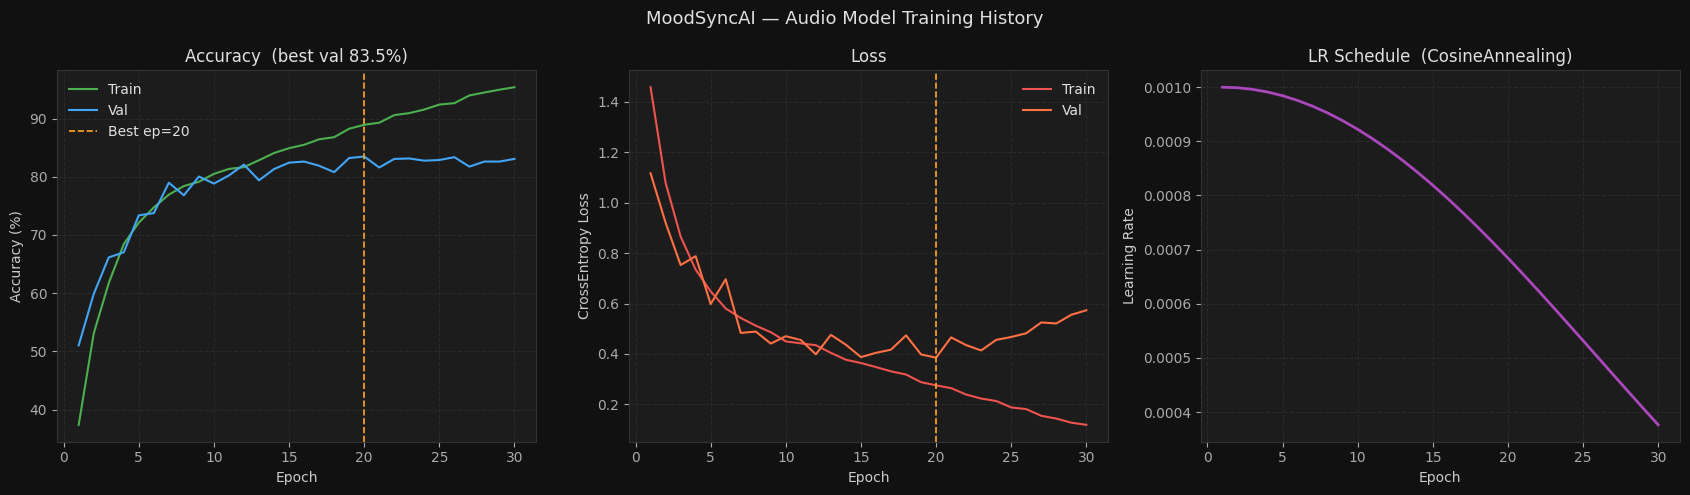

In [31]:
ep = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(ep, [a*100 for a in history["train_acc"]], color="#4CAF50",  label="Train")
axes[0].plot(ep, [a*100 for a in history["val_acc"]],   color="#42A5F5",  label="Val")
axes[0].axvline(best_epoch, color="#FFA726", linestyle="--", linewidth=1.2, label=f"Best ep={best_epoch}")
axes[0].set_title(f"Accuracy  (best val {best_val_acc*100:.1f}%)", color="#e0e0e0")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(framealpha=0); axes[0].grid(True)

axes[1].plot(ep, history["train_loss"], color="#EF5350", label="Train")
axes[1].plot(ep, history["val_loss"],   color="#FF7043", label="Val")
axes[1].axvline(best_epoch, color="#FFA726", linestyle="--", linewidth=1.2)
axes[1].set_title("Loss", color="#e0e0e0")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("CrossEntropy Loss")
axes[1].legend(framealpha=0); axes[1].grid(True)

axes[2].plot(ep, history["lr"], color="#AB47BC", linewidth=2)
axes[2].set_title("LR Schedule  (CosineAnnealing)", color="#e0e0e0")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning Rate")
axes[2].grid(True)

plt.suptitle("MoodSyncAI — Audio Model Training History", fontsize=13, color="#e0e0e0")
plt.tight_layout()
plt.savefig("audio_training_curves.png", dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show()

## 11  Evaluation on Test Set

In [32]:
model.load_state_dict(torch.load(SAVE_DIR / "best_audio_model.pt", map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()    # ← all 7 class probs
        preds  = probs.argmax(axis=1)
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)   # (N_test, 7)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy : {test_acc*100:.2f}%")
print()
print(classification_report(all_labels, all_preds, target_names=le.classes_, digits=4))


Test Accuracy : 83.16%

              precision    recall  f1-score   support

       angry     0.9747    1.0000    0.9872       231
     disgust     0.8551    0.7007    0.7702       421
        fear     0.7627    0.7500    0.7563       420
       happy     0.8293    0.8214    0.8254       420
     neutral     0.8626    0.8439    0.8531       506
         sad     0.7031    0.8551    0.7717       421
    surprise     0.9957    1.0000    0.9978       229

    accuracy                         0.8316      2648
   macro avg     0.8547    0.8530    0.8517      2648
weighted avg     0.8362    0.8316    0.8315      2648



## 12  Confusion Matrix

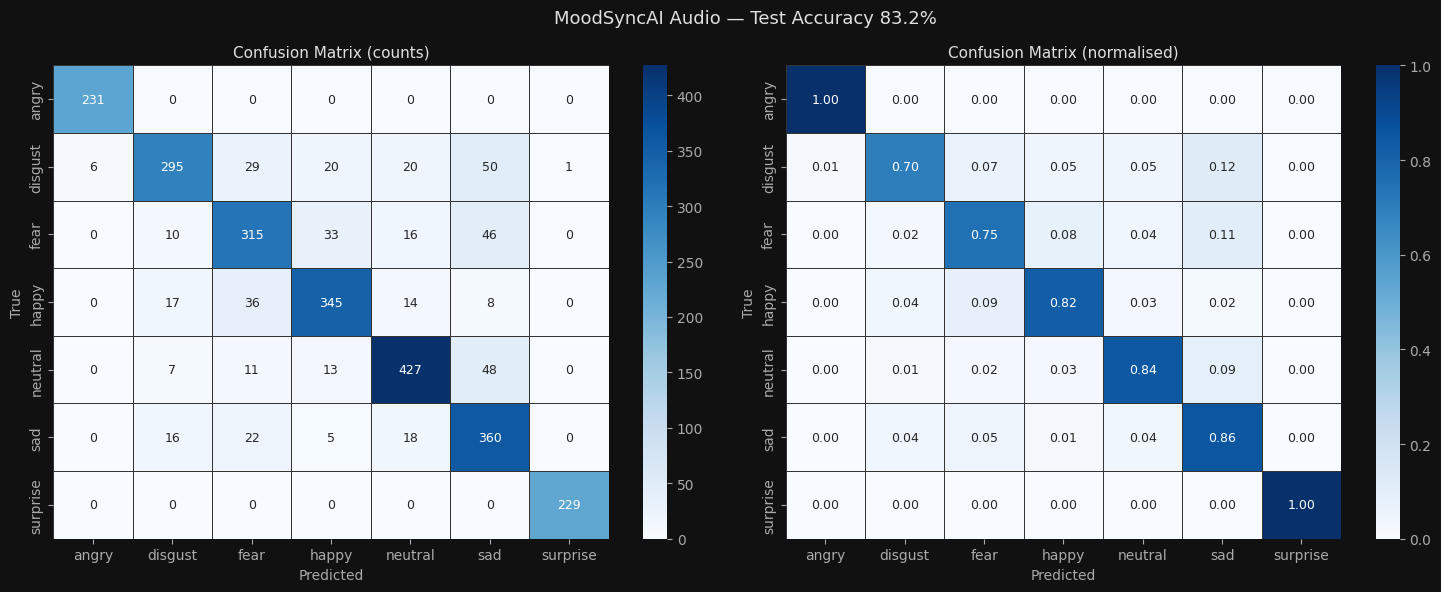

In [33]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, data, title, fmt in zip(
        axes,
        [cm,      cm_norm],
        ["Confusion Matrix (counts)", "Confusion Matrix (normalised)"],
        ["d",     ".2f"]):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, cbar=True, linewidths=0.5, linecolor="#333333",
                annot_kws={"size": 9})
    ax.set_title(title, fontsize=11, color="#e0e0e0")
    ax.set_xlabel("Predicted", color="#aaaaaa")
    ax.set_ylabel("True",      color="#aaaaaa")

plt.suptitle(f"MoodSyncAI Audio — Test Accuracy {test_acc*100:.1f}%",
             fontsize=13, color="#e0e0e0")
plt.tight_layout()
plt.savefig("audio_confusion_matrix.png", dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show()


## 13  Full 7-Class Probability Output Visualisation

This section demonstrates that the model outputs **all 7 emotion probabilities** for every input — not just the top class.
This is the primary output that will feed into the audio-text fusion notebook.

The probability bars for all 7 emotions are shown side-by-side for sample clips from the test set.

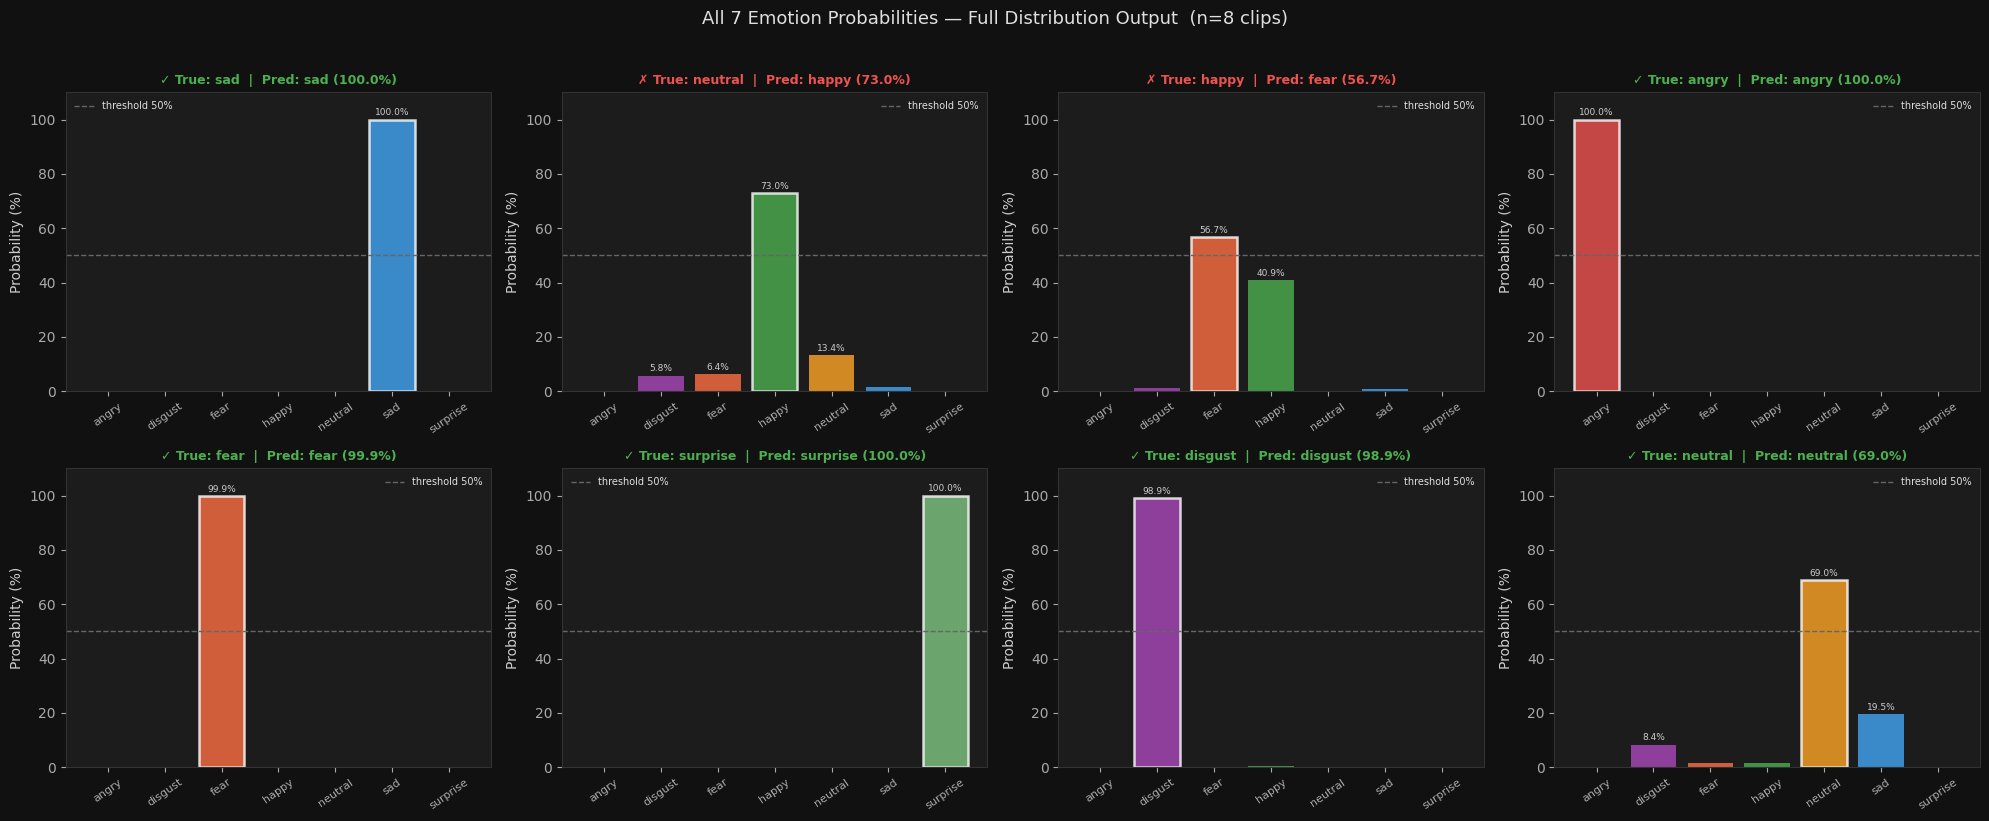

Saved audio_7class_probabilities.png


In [34]:
def plot_7class_probabilities(probs_array: np.ndarray,
                               true_labels: np.ndarray,
                               n_samples: int = 8,
                               title_prefix: str = "Test Sample"):
    """
    Plot all 7 emotion probabilities for n_samples test clips.
    This is the PRIMARY output format — all 7 classes are shown, not just the top.
    """
    n_cols = 4
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()

    # pick one sample per emotion, then random
    shown_emotions = set()
    indices = []
    for i, lbl in enumerate(all_labels):
        emo = le.classes_[lbl]
        if emo not in shown_emotions:
            indices.append(i)
            shown_emotions.add(emo)
    remaining = [i for i in range(len(all_labels)) if i not in indices]
    indices  += random.sample(remaining, max(0, n_samples - len(indices)))
    indices   = indices[:n_samples]

    for ax_idx, sample_idx in enumerate(indices):
        probs      = probs_array[sample_idx]          # shape (7,)
        true_emo   = le.classes_[true_labels[sample_idx]]
        pred_idx   = probs.argmax()
        pred_emo   = le.classes_[pred_idx]
        pred_conf  = probs[pred_idx]

        # colour each bar by emotion; highlight top prediction
        colours = [EMOTION_COLOURS[emo] for emo in le.classes_]
        bars = axes[ax_idx].bar(le.classes_, probs * 100,
                                color=colours, alpha=0.80, edgecolor="none")
        # white edge on top prediction
        bars[pred_idx].set_edgecolor("white"); bars[pred_idx].set_linewidth(1.8)

        # dashed line at conf threshold
        axes[ax_idx].axhline(CONF_THRESHOLD * 100, color="#666666",
                             linestyle="--", linewidth=1.0, label=f"threshold {CONF_THRESHOLD:.0%}")

        # annotate each bar with its probability
        for bar, p in zip(bars, probs):
            if p > 0.02:
                axes[ax_idx].text(bar.get_x() + bar.get_width()/2,
                                  bar.get_height() + 0.8,
                                  f"{p*100:.1f}%",
                                  ha="center", va="bottom", fontsize=6.5,
                                  color="#cccccc")

        correct  = "✓" if pred_emo == true_emo else "✗"
        title_col= "#4CAF50" if pred_emo == true_emo else "#EF5350"
        axes[ax_idx].set_title(
            f"{correct} True: {true_emo}  |  Pred: {pred_emo} ({pred_conf*100:.1f}%)",
            fontsize=9, color=title_col, fontweight="bold")
        axes[ax_idx].set_ylim(0, 110)
        axes[ax_idx].set_ylabel("Probability (%)")
        axes[ax_idx].tick_params(axis="x", rotation=35, labelsize=8)
        axes[ax_idx].legend(fontsize=7, framealpha=0)

    # hide unused axes
    for j in range(len(indices), len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        f"All 7 Emotion Probabilities — Full Distribution Output  (n={len(indices)} clips)",
        fontsize=13, color="#e0e0e0", y=1.02)
    plt.tight_layout()
    plt.savefig("audio_7class_probabilities.png", dpi=150,
                bbox_inches="tight", facecolor="#111111")
    plt.show()
    print("Saved audio_7class_probabilities.png")


plot_7class_probabilities(all_probs, all_labels, n_samples=8)


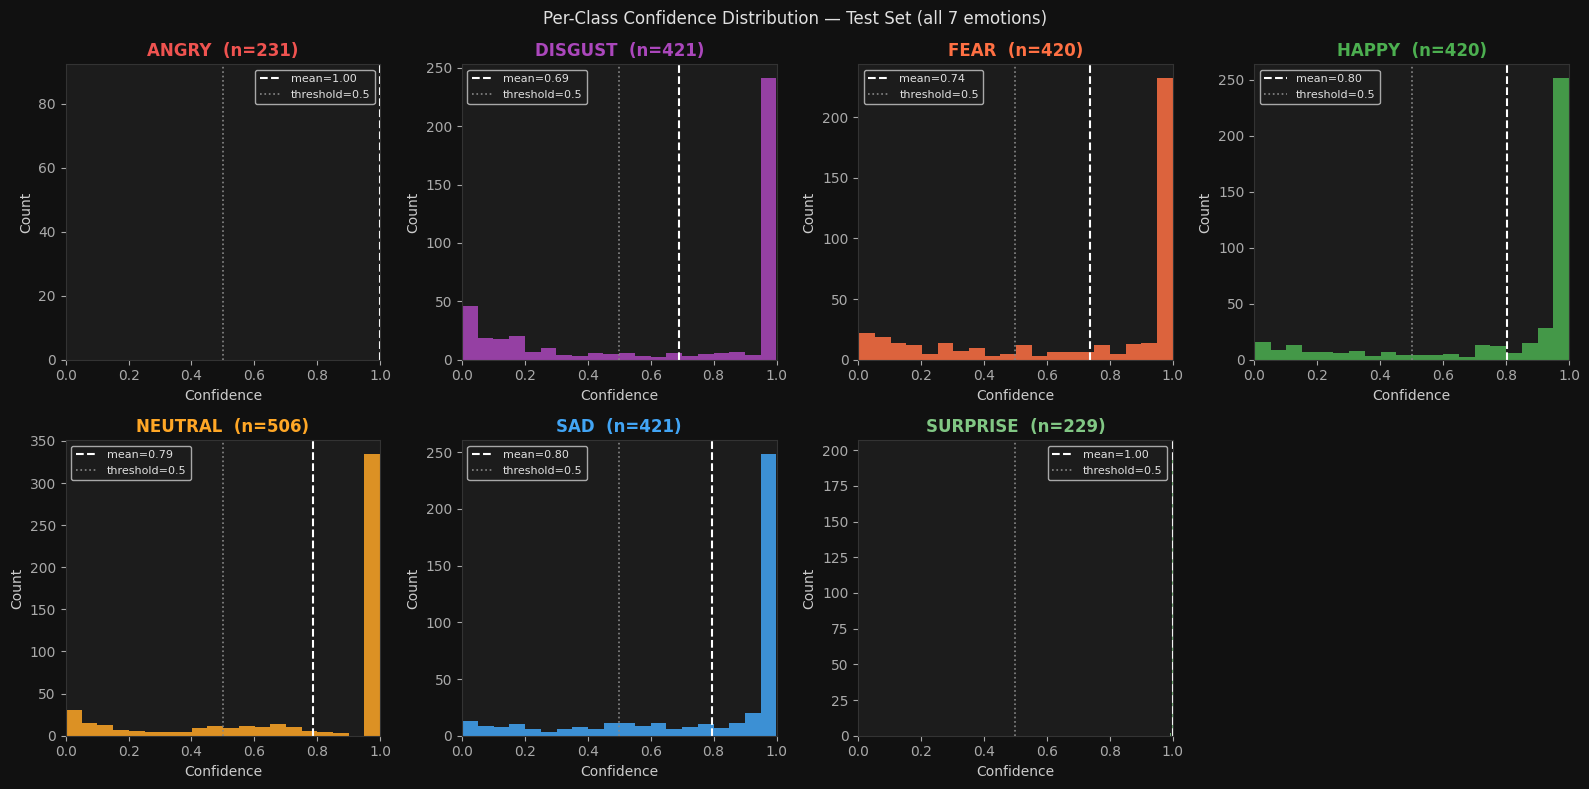

In [35]:
# ── Per-class confidence distribution (all 7 emotions) ───────────────────────
conf_by_class = {emo: [] for emo in le.classes_}
for probs_row, true_idx in zip(all_probs, all_labels):
    conf_by_class[le.classes_[true_idx]].append(probs_row[true_idx])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, emo in enumerate(le.classes_):
    data = conf_by_class[emo]
    axes[i].hist(data, bins=20, color=EMOTION_COLOURS[emo], alpha=0.85, edgecolor="none")
    axes[i].axvline(np.mean(data), color="white", linestyle="--", linewidth=1.5,
                    label=f"mean={np.mean(data):.2f}")
    axes[i].axvline(CONF_THRESHOLD, color="#888888", linestyle=":", linewidth=1.2,
                    label=f"threshold={CONF_THRESHOLD}")
    axes[i].set_title(f"{emo.upper()}  (n={len(data)})", color=EMOTION_COLOURS[emo], fontweight="bold")
    axes[i].set_xlabel("Confidence"); axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(0, 1)

axes[-1].axis("off")
plt.suptitle("Per-Class Confidence Distribution — Test Set (all 7 emotions)",
             fontsize=12, color="#e0e0e0")
plt.tight_layout()
plt.savefig("audio_confidence_dist.png", dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show()

## 14  Latency Benchmark

In [36]:
sample_audio = all_records[0]["audio"]
sample_sr    = all_records[0]["sr"]

for _ in range(5):   # warmup
    feat = extract_features(sample_audio, sample_sr)
    with torch.no_grad():
        _ = torch.softmax(model(torch.tensor(feat).unsqueeze(0).to(DEVICE)), dim=1)

times = []
for _ in range(50):
    t0   = time.perf_counter()
    feat = extract_features(sample_audio, sample_sr)
    inp  = torch.tensor(feat).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs_out = torch.softmax(model(inp), dim=1).squeeze().cpu().numpy()   # all 7 probs
    times.append((time.perf_counter() - t0) * 1000)

print(f"End-to-end latency (feature extraction + 7-class inference):")
print(f"  Mean   : {np.mean(times):.1f} ms")
print(f"  Median : {np.median(times):.1f} ms")
print(f"  p95    : {np.percentile(times, 95):.1f} ms")
print(f"  Output : {probs_out}  ← all 7 probabilities")
print(f"  Sum    : {probs_out.sum():.6f}  (should be 1.0)")
print(f"Real-time: {'Yes ✓' if np.median(times) < 500 else 'Consider batching'} (target <500 ms)")

End-to-end latency (feature extraction + 7-class inference):
  Mean   : 7.6 ms
  Median : 7.6 ms
  p95    : 7.6 ms
  Output : [7.4002645e-07 3.1694508e-05 1.0927530e-06 5.8204012e-05 9.9979800e-01
 7.1781054e-05 3.8475751e-05]  ← all 7 probabilities
  Sum    : 1.000000  (should be 1.0)
Real-time: Yes ✓ (target <500 ms)


## 15  Save Model & Metadata

In [37]:
torch.save(model.state_dict(), SAVE_DIR / "best_audio_model.pt")

meta = {
    "model_arch"         : "1D-CNN(×4) + BiLSTM(×2) + FC",
    "primary_output"     : "7-class emotion probability distribution",
    "emotion_classes"    : list(le.classes_),
    "num_classes"        : NUM_CLASSES,
    "audio_to_polarity"  : AUDIO_TO_POLARITY,
    "conf_threshold"     : CONF_THRESHOLD,
    "sample_rate"        : SAMPLE_RATE,
    "max_duration_s"     : MAX_DURATION,
    "feature_dim"        : 198,
    "test_accuracy"      : round(float(test_acc), 4),
    "best_val_accuracy"  : round(float(best_val_acc), 4),
    "best_epoch"         : best_epoch,
    "polarity_bridge"    : "happy/surprise→positive | neutral→neutral | angry/disgust/fear/sad→negative",
    "note"               : "probs key always contains all 7 class probabilities",
}
with open(SAVE_DIR / "audio_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved model    → {SAVE_DIR / 'best_audio_model.pt'}")
print(f"Saved encoder  → {SAVE_DIR / 'label_encoder.pkl'}")
print(f"Saved metadata → {SAVE_DIR / 'audio_model_meta.json'}")
print()
print(json.dumps(meta, indent=2))

Saved model    → saved_models/audio_emotion/best_audio_model.pt
Saved encoder  → saved_models/audio_emotion/label_encoder.pkl
Saved metadata → saved_models/audio_emotion/audio_model_meta.json

{
  "model_arch": "1D-CNN(\u00d74) + BiLSTM(\u00d72) + FC",
  "primary_output": "7-class emotion probability distribution",
  "emotion_classes": [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
  ],
  "num_classes": 7,
  "audio_to_polarity": {
    "happy": "positive",
    "surprise": "positive",
    "neutral": "neutral",
    "angry": "negative",
    "disgust": "negative",
    "fear": "negative",
    "sad": "negative"
  },
  "conf_threshold": 0.5,
  "sample_rate": 16000,
  "max_duration_s": 3.0,
  "feature_dim": 198,
  "test_accuracy": 0.8316,
  "best_val_accuracy": 0.8349,
  "best_epoch": 20,
  "polarity_bridge": "happy/surprise\u2192positive | neutral\u2192neutral | angry/disgust/fear/sad\u2192negative",
  "note": "probs key always contains all 7 cl

## 16  Production Inference — `predict_audio()`

### Return Schema
```python
{
    "emotion"    : "happy",          # top predicted emotion (one of 7 classes)
    "emotion_id" : 3,                # integer index 0–6
    "confidence" : 0.8732,           # probability of the top class (0.0–1.0)
    "polarity"   : "positive",       # derived field for fusion (negative/neutral/positive)
    "probs"      : {                 # ← PRIMARY OUTPUT: ALL 7 EMOTION PROBABILITIES
        "angry"   : 0.0231,
        "disgust" : 0.0118,
        "fear"    : 0.0419,
        "happy"   : 0.8732,          # ← top class
        "neutral" : 0.0312,
        "sad"     : 0.0098,
        "surprise": 0.0090,
    }
}
```

> **Note:** `probs` always sums to 1.0 and contains all 7 classes regardless of
> which emotion is predicted. This is the value consumed by the audio-text fusion notebook.

In [38]:
def predict_audio(audio_path: str,
                  model=model,
                  le=le,
                  device=DEVICE) -> dict:
    """
    Run audio emotion inference on a file.

    Primary output: all 7 emotion class probabilities.
    Secondary output: top emotion, confidence, and polarity bridge.

    Parameters
    ----------
    audio_path : path to .wav / .mp3 / .flac file

    Returns
    -------
    dict:
        emotion     - top predicted emotion  (one of 7 classes)
        emotion_id  - integer index 0–6
        confidence  - probability of top class (0.0–1.0)
        polarity    - 'negative' | 'neutral' | 'positive'  (for fusion)
        probs       - {emotion: float} for ALL 7 classes  ← PRIMARY
    """
    audio, sr = librosa.load(audio_path, sr=None, mono=True)
    feat      = extract_features(audio, sr)
    inp       = torch.tensor(feat).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(inp)                                        # raw logits (1, 7)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()  # (7,) — all classes

    top_id  = int(probs.argmax())
    emotion = le.classes_[top_id]

    return {
        "emotion"   : emotion,
        "emotion_id": top_id,
        "confidence": round(float(probs[top_id]), 4),
        "polarity"  : AUDIO_TO_POLARITY[emotion],
        # ── ALL 7 emotion probabilities — primary output ──────────────────────
        "probs": {le.classes_[i]: round(float(probs[i]), 4) for i in range(NUM_CLASSES)},
    }


print("predict_audio() defined.")
print()
print("Return schema:")
print("  result['emotion']    → top emotion class  (e.g. 'happy')")
print("  result['confidence'] → probability of top class  (e.g. 0.8732)")
print("  result['polarity']   → fusion polarity  (e.g. 'positive')")
print("  result['probs']      → ALL 7 emotion probabilities  ← primary output")
print()
print("Example output structure:")
example = {
    "emotion"   : "happy",
    "emotion_id": 3,
    "confidence": 0.8732,
    "polarity"  : "positive",
    "probs"     : {emo: round(1/7 + random.gauss(0, 0.05), 4) for emo in EMOTION_CLASSES},
}
# normalise example probs for display
total = sum(example["probs"].values())
example["probs"] = {k: round(v/total, 4) for k, v in example["probs"].items()}
example["probs"]["happy"] = example["confidence"]  # force top
print(json.dumps(example, indent=4))

predict_audio() defined.

Return schema:
  result['emotion']    → top emotion class  (e.g. 'happy')
  result['confidence'] → probability of top class  (e.g. 0.8732)
  result['polarity']   → fusion polarity  (e.g. 'positive')
  result['probs']      → ALL 7 emotion probabilities  ← primary output

Example output structure:
{
    "emotion": "happy",
    "emotion_id": 3,
    "confidence": 0.8732,
    "polarity": "positive",
    "probs": {
        "angry": 0.1722,
        "disgust": 0.1638,
        "fear": 0.1202,
        "happy": 0.8732,
        "neutral": 0.1745,
        "sad": 0.1608,
        "surprise": 0.0659
    }
}


## 17  Demo — All 7 Probabilities from a Single Clip

This cell shows how to interpret the full probability output.
Replace `"path/to/your_audio.wav"` with any real audio file to run live inference.

Running demo on one sample per emotion class:

  Ground truth : ANGRY
  Predicted    : ANGRY  (100.0%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  angry     :  99.98%  █████████████████████████████ ← top
  disgust   :   0.02%  
  fear      :   0.00%  
  happy     :   0.00%  
  neutral   :   0.00%  
  sad       :   0.00%  
  surprise  :   0.00%  
  ----------------------------------------
  Sum of probs : 1.0000  (should be 1.0000)


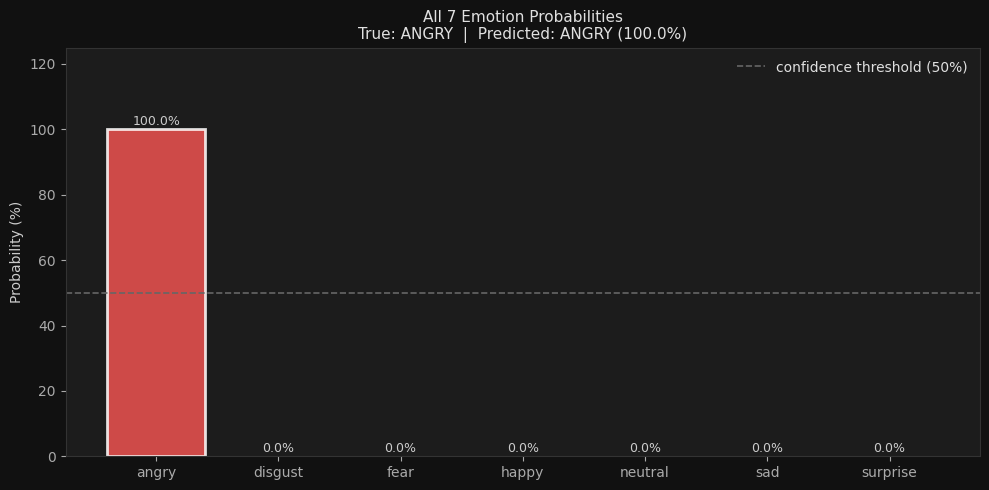


  Ground truth : DISGUST
  Predicted    : DISGUST  (100.0%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  disgust   :  99.99%  █████████████████████████████ ← top
  angry     :   0.00%  
  fear      :   0.00%  
  happy     :   0.00%  
  neutral   :   0.00%  
  sad       :   0.00%  
  surprise  :   0.00%  
  ----------------------------------------
  Sum of probs : 0.9999  (should be 1.0000)


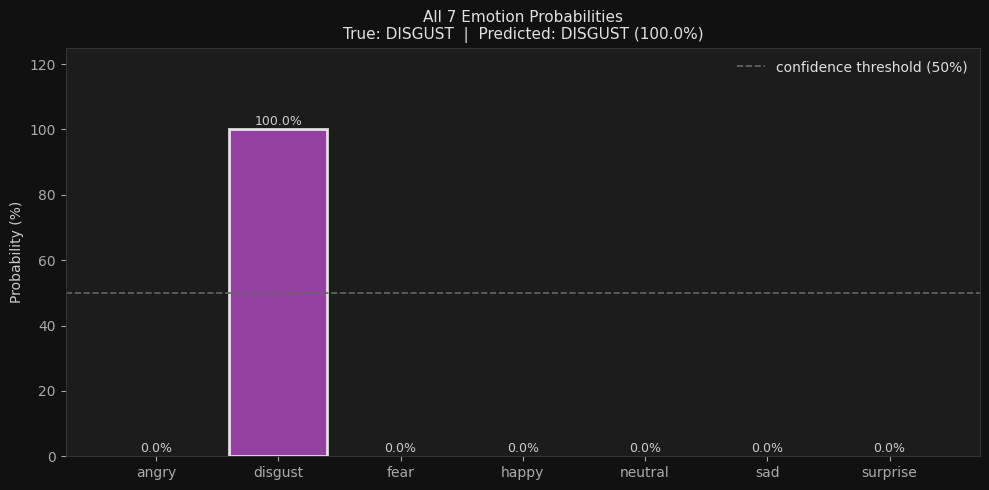


  Ground truth : FEAR
  Predicted    : FEAR  (99.9%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  fear      :  99.85%  █████████████████████████████ ← top
  happy     :   0.13%  
  sad       :   0.02%  
  angry     :   0.00%  
  disgust   :   0.00%  
  neutral   :   0.00%  
  surprise  :   0.00%  
  ----------------------------------------
  Sum of probs : 1.0000  (should be 1.0000)


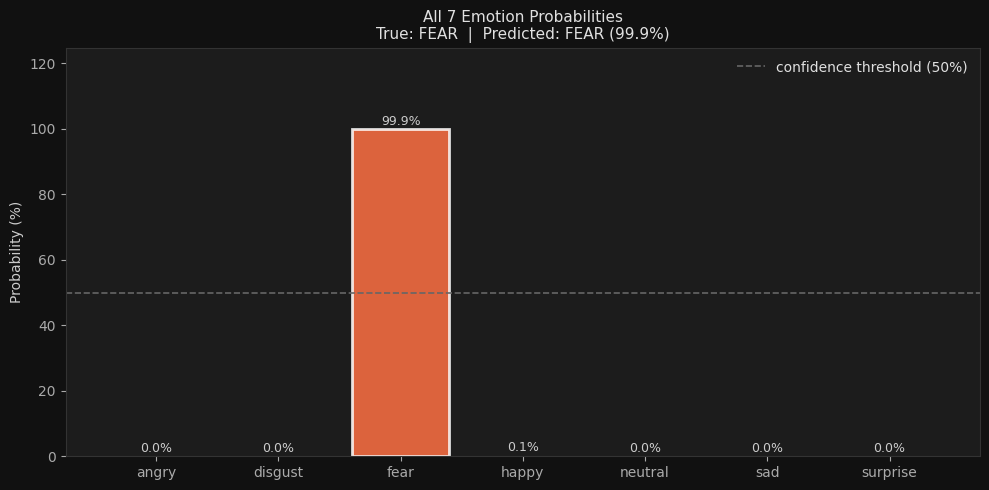


  Ground truth : HAPPY
  Predicted    : HAPPY  (100.0%)
  Polarity     : positive

  All 7 Emotion Probabilities:
  ----------------------------------------
  happy     :  99.98%  █████████████████████████████ ← top
  fear      :   0.01%  
  sad       :   0.01%  
  angry     :   0.00%  
  disgust   :   0.00%  
  neutral   :   0.00%  
  surprise  :   0.00%  
  ----------------------------------------
  Sum of probs : 1.0000  (should be 1.0000)


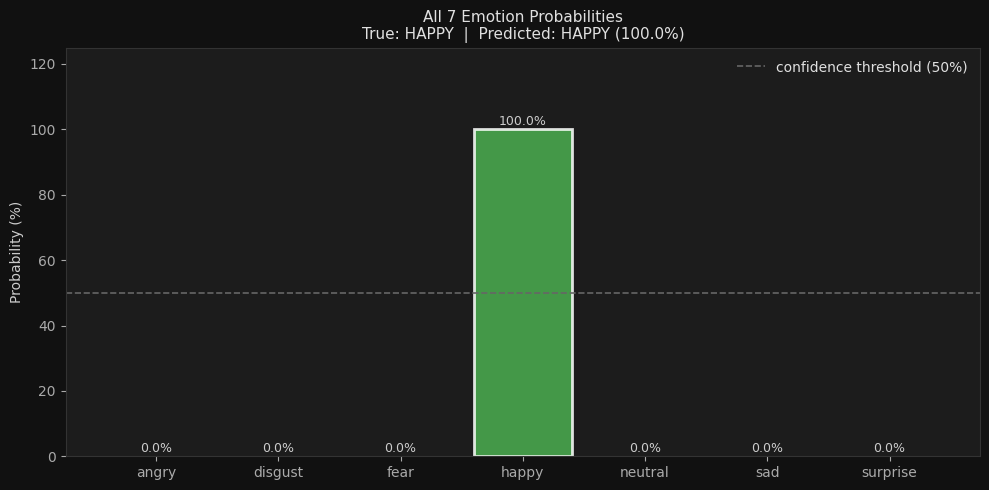


  Ground truth : NEUTRAL
  Predicted    : NEUTRAL  (100.0%)
  Polarity     : neutral

  All 7 Emotion Probabilities:
  ----------------------------------------
  neutral   :  99.98%  █████████████████████████████ ← top
  happy     :   0.01%  
  sad       :   0.01%  
  angry     :   0.00%  
  disgust   :   0.00%  
  fear      :   0.00%  
  surprise  :   0.00%  
  ----------------------------------------
  Sum of probs : 1.0000  (should be 1.0000)


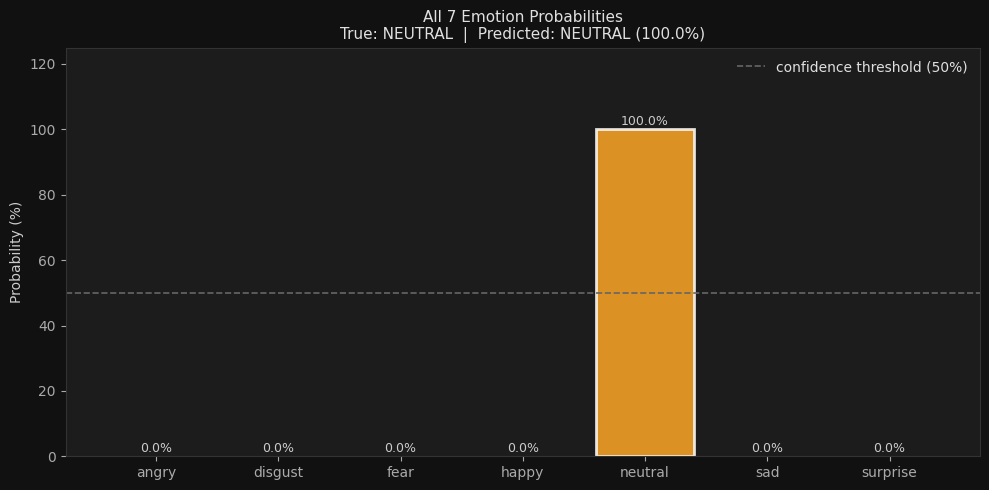


  Ground truth : SAD
  Predicted    : SAD  (99.8%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  sad       :  99.84%  █████████████████████████████ ← top
  neutral   :   0.09%  
  fear      :   0.06%  
  happy     :   0.01%  
  angry     :   0.00%  
  disgust   :   0.00%  
  surprise  :   0.00%  
  ----------------------------------------
  Sum of probs : 1.0000  (should be 1.0000)


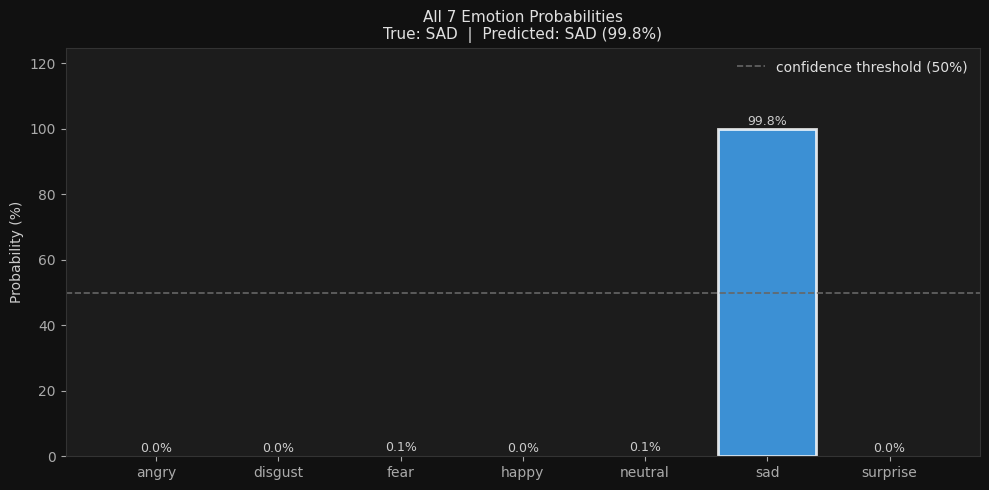


  Ground truth : SURPRISE
  Predicted    : SURPRISE  (100.0%)
  Polarity     : positive

  All 7 Emotion Probabilities:
  ----------------------------------------
  surprise  :  99.99%  █████████████████████████████ ← top
  angry     :   0.01%  
  disgust   :   0.00%  
  fear      :   0.00%  
  happy     :   0.00%  
  neutral   :   0.00%  
  sad       :   0.00%  
  ----------------------------------------
  Sum of probs : 1.0000  (should be 1.0000)


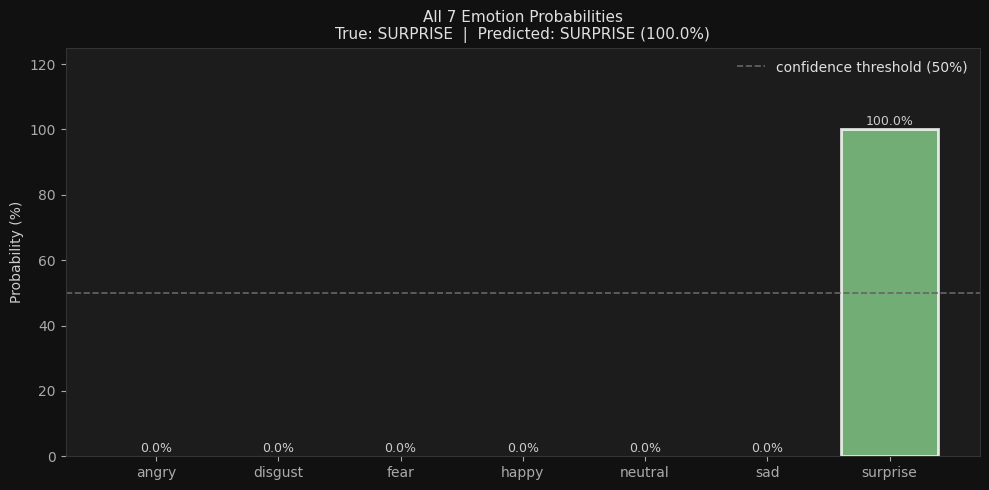

In [40]:
def demo_predict_audio_from_array(audio_array: np.ndarray, sr: int, label: str = "unknown"):
    """
    Demo wrapper — runs predict_audio on an in-memory audio array
    (avoids file I/O for demonstration).
    """
    feat   = extract_features(audio_array, sr)
    inp    = torch.tensor(feat).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(inp), dim=1).squeeze().cpu().numpy()   # all 7

    top_id  = int(probs.argmax())
    emotion = le.classes_[top_id]
    result  = {
        "emotion"   : emotion,
        "emotion_id": top_id,
        "confidence": round(float(probs[top_id]), 4),
        "polarity"  : AUDIO_TO_POLARITY[emotion],
        "probs"     : {le.classes_[i]: round(float(probs[i]), 4) for i in range(NUM_CLASSES)},
    }

    # ── print full 7-class distribution ───────────────────────────────────────
    print("=" * 55)
    print(f"  Ground truth : {label.upper()}")
    print(f"  Predicted    : {result['emotion'].upper()}  ({result['confidence']*100:.1f}%)")
    print(f"  Polarity     : {result['polarity']}")
    print()
    print("  All 7 Emotion Probabilities:")
    print("  " + "-" * 40)
    for emo, prob in sorted(result["probs"].items(), key=lambda x: -x[1]):
        bar    = "█" * int(prob * 30)
        marker = " ← top" if emo == result["emotion"] else ""
        print(f"  {emo:10s}: {prob*100:6.2f}%  {bar}{marker}")
    print("  " + "-" * 40)
    print(f"  Sum of probs : {sum(result['probs'].values()):.4f}  (should be 1.0000)")
    print("=" * 55)

    # ── bar chart of all 7 probabilities ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    emotions = list(result["probs"].keys())
    vals     = [result["probs"][e] * 100 for e in emotions]
    colours  = [EMOTION_COLOURS[e] for e in emotions]
    bars     = ax.bar(emotions, vals, color=colours, alpha=0.85, edgecolor="none")
    bars[emotions.index(result["emotion"])].set_edgecolor("white")
    bars[emotions.index(result["emotion"])].set_linewidth(2)

    ax.axhline(CONF_THRESHOLD * 100, color="#666666", linestyle="--", linewidth=1.2,
               label=f"confidence threshold ({CONF_THRESHOLD:.0%})")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color="#cccccc")

    ax.set_title(
    f"All 7 Emotion Probabilities\n"
    f"True: {label.upper()}  |  Predicted: {result['emotion'].upper()} ({result['confidence']*100:.1f}%)",
    fontsize=11, color="#e0e0e0")
    ax.set_ylabel("Probability (%)")
    ax.set_ylim(0, max(vals) * 1.25)
    ax.legend(framealpha=0)
    plt.tight_layout()
    plt.savefig("audio_demo_7class.png", dpi=150, bbox_inches="tight", facecolor="#111111")
    plt.show()
    return result


# ── Run demo on one sample per emotion ────────────────────────────────────────
print("Running demo on one sample per emotion class:\n")
for target_emo in EMOTION_CLASSES:
    idx = df[df["label"] == target_emo].index[0]
    rec = all_records[idx]
    demo_predict_audio_from_array(rec["audio"], rec["sr"], label=target_emo)
    print()

In [ ]:
# ── Usage with a real file ─────────────────────────────────────────────────────
print("""
To run on a real audio file:

    result = predict_audio("path/to/your_clip.wav")

    # Primary output — all 7 probabilities:
    print(result["probs"])
    # {
    #   'angry'   : 0.0231,
    #   'disgust' : 0.0118,
    #   'fear'    : 0.0419,
    #   'happy'   : 0.8732,  ← top
    #   'neutral' : 0.0312,
    #   'sad'     : 0.0098,
    #   'surprise': 0.0090
    # }

    # Top emotion:
    print(result["emotion"])      # 'happy'
    print(result["confidence"])   # 0.8732

    # Fusion polarity (secondary):
    print(result["polarity"])     # 'positive'
""")


## 18  Integration Snippet — `models/audio/audio_emotion_model.py`

In [ ]:
integration = '''
# models/audio/audio_emotion_model.py
# ─────────────────────────────────────────────────────────────
# Drop-in module for MoodSyncAI.
# Mirrors the interface of models/visual/cnn_emotion.py and
# models/text/sentiment_model.py — same return-dict schema.
#
# Primary output: probs → all 7 emotion class probabilities
# Secondary:      emotion, confidence, polarity  (for fusion)

import pickle, json, numpy as np, torch, torch.nn as nn, librosa
from pathlib import Path

SAVE_DIR    = Path("saved_models/audio_emotion")
SAMPLE_RATE = 16_000
MAX_DURATION= 3.0
N_MFCC, N_MELS, HOP_LENGTH, N_FFT = 40, 64, 512, 2048
MAX_SAMPLES = int(MAX_DURATION * SAMPLE_RATE)
NUM_CLASSES = 7

AUDIO_TO_POLARITY = {
    "happy":"positive","surprise":"positive","neutral":"neutral",
    "angry":"negative","disgust":"negative","fear":"negative","sad":"negative",
}

class AudioEmotionNet(nn.Module):
    def __init__(self, in_channels=198, num_classes=NUM_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels,256,3,padding=1), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.25),
            nn.Conv1d(256,256,3,padding=1), nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.25),
            nn.Conv1d(256,512,3,padding=1), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.25),
            nn.Conv1d(512,512,3,padding=1), nn.BatchNorm1d(512), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.25),
        )
        self.lstm = nn.LSTM(512, 256, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.classifier = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,num_classes))
    def forward(self, x):
        x = self.cnn(x); x = x.permute(0,2,1); out,_ = self.lstm(x)
        return self.classifier(out[:,-1,:])

def _extract_features(audio, sr):
    audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
    if len(audio) >= MAX_SAMPLES: audio = audio[:MAX_SAMPLES]
    else: audio = np.pad(audio, (0, MAX_SAMPLES - len(audio)))
    mfcc   = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    d_mfcc = librosa.feature.delta(mfcc); dd_mfcc = librosa.feature.delta(mfcc, order=2)
    mel    = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS,
                                 n_fft=N_FFT, hop_length=HOP_LENGTH), ref=np.max)
    chroma = librosa.feature.chroma_stft(y=audio, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH)
    zcr    = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)
    rms    = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)
    def norm(x): return (x - x.mean(axis=1,keepdims=True)) / (x.std(axis=1,keepdims=True) + 1e-8)
    return np.concatenate([norm(mfcc),norm(d_mfcc),norm(dd_mfcc),
                           norm(mel),norm(chroma),norm(zcr),norm(rms)],axis=0).astype(np.float32)

class AudioEmotionModel:
    def __init__(self, model_dir=str(SAVE_DIR)):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        with open(Path(model_dir)/"label_encoder.pkl","rb") as f: self.le = pickle.load(f)
        self.model = AudioEmotionNet().to(self.device)
        self.model.load_state_dict(torch.load(Path(model_dir)/"best_audio_model.pt", map_location=self.device))
        self.model.eval()

    def predict(self, audio_path: str) -> dict:
        """Returns all 7 emotion class probabilities as primary output."""
        audio, sr = librosa.load(audio_path, sr=None, mono=True)
        feat      = _extract_features(audio, sr)
        inp       = torch.tensor(feat).unsqueeze(0).to(self.device)
        with torch.no_grad():
            probs = torch.softmax(self.model(inp), dim=1).squeeze().cpu().numpy()  # (7,)
        top_id  = int(probs.argmax())
        emotion = self.le.classes_[top_id]
        return {
            "emotion"   : emotion,
            "emotion_id": top_id,
            "confidence": round(float(probs[top_id]), 4),
            "polarity"  : AUDIO_TO_POLARITY[emotion],
            # ── ALL 7 emotion probabilities ─────────────────────────────────
            "probs": {self.le.classes_[i]: round(float(probs[i]), 4)
                      for i in range(NUM_CLASSES)},
        }

# Usage:
# audio_model = AudioEmotionModel()
# result = audio_model.predict("clip.wav")
# print(result["probs"])  # → {"angry":0.02,"disgust":0.01,...,"happy":0.87,...}
'''
print(integration)


## 19  Notebook Summary

In [41]:
print("=" * 65)
print("  04 Audio Emotion Recognition — Key Decisions")
print("=" * 65)
summary = {
    "Datasets"          : "RAVDESS + CREMA-D (Hugging Face)",
    "Total samples"     : len(all_records),
    "Emotion classes"   : " | ".join(EMOTION_CLASSES),
    "Primary output"    : "All 7 emotion probabilities (probs dict)",
    "Feature dim"       : "198 (MFCC×3=120 + Mel=64 + Chroma=12 + ZCR+RMS=2)",
    "Architecture"      : "1D-CNN(×4) → BiLSTM(×2) → FC(×2) → 7 classes",
    "Optimiser"         : "Adam  lr=1e-3  wd=1e-4",
    "Scheduler"         : "CosineAnnealingLR  T_max=50",
    "Early stopping"    : f"patience=10  |  best epoch={best_epoch}",
    "Best val accuracy" : f"{best_val_acc*100:.2f}%",
    "Test accuracy"     : f"{test_acc*100:.2f}%",
    "Polarity bridge"   : "secondary field — happy/surprise→pos | neutral→neu | rest→neg",
    "Saved model"       : str(SAVE_DIR / "best_audio_model.pt"),
    "Saved encoder"     : str(SAVE_DIR / "label_encoder.pkl"),
}
for k, v in summary.items():
    print(f"  {k:22s}: {v}")
print("=" * 65)
print()
print("  Next step → 05_audio_text_fusion.ipynb")
print("  predict_audio() → result['probs'] contains all 7 probabilities")
print("  Pair with predict_text() (RoBERTa) for audio-text fusion")


  04 Audio Emotion Recognition — Key Decisions
  Datasets              : RAVDESS + CREMA-D (Hugging Face)
  Total samples         : 17691
  Emotion classes       : angry | disgust | fear | happy | neutral | sad | surprise
  Primary output        : All 7 emotion probabilities (probs dict)
  Feature dim           : 198 (MFCC×3=120 + Mel=64 + Chroma=12 + ZCR+RMS=2)
  Architecture          : 1D-CNN(×4) → BiLSTM(×2) → FC(×2) → 7 classes
  Optimiser             : Adam  lr=1e-3  wd=1e-4
  Scheduler             : CosineAnnealingLR  T_max=50
  Early stopping        : patience=10  |  best epoch=20
  Best val accuracy     : 83.49%
  Test accuracy         : 83.16%
  Polarity bridge       : secondary field — happy/surprise→pos | neutral→neu | rest→neg
  Saved model           : saved_models/audio_emotion/best_audio_model.pt
  Saved encoder         : saved_models/audio_emotion/label_encoder.pkl

  Next step → 05_audio_text_fusion.ipynb
  predict_audio() → result['probs'] contains all 7 probabilities


In [43]:
import IPython.display as ipd
import ipywidgets as widgets

def play_predicted_sample(target_emotion: str = None, idx: int = None):
    """
    Play an audio sample and show its prediction.
    - target_emotion: pick a random sample of that emotion (e.g. "happy")
    - idx: or pick a specific index from all_records directly
    """
    if idx is not None:
        rec = all_records[idx]
    elif target_emotion is not None:
        candidates = [i for i, r in enumerate(all_records) if r["label"] == target_emotion]
        idx = np.random.choice(candidates)
        rec = all_records[idx]
    else:
        idx = np.random.randint(len(all_records))
        rec = all_records[idx]

    # ── Run prediction ─────────────────────────────────────────────────────
    feat = extract_features(rec["audio"], rec["sr"])
    inp  = torch.tensor(feat).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(inp), dim=1).squeeze().cpu().numpy()

    top_id     = int(probs.argmax())
    predicted  = le.classes_[top_id]
    confidence = probs[top_id]
    ground     = rec["label"]
    correct    = "✅" if predicted == ground else "❌"

    # ── Print result ────────────────────────────────────────────────────────
    print(f"  Source     : {rec.get('source', 'unknown')}  (index {idx})")
    print(f"  Ground truth : {ground.upper()}")
    print(f"  Predicted    : {predicted.upper()}  ({confidence*100:.1f}%)  {correct}")
    print()
    for emo, prob in sorted(
        {le.classes_[i]: probs[i] for i in range(NUM_CLASSES)}.items(),
        key=lambda x: -x[1]
    ):
        bar    = "█" * int(prob * 30)
        marker = " ← predicted" if emo == predicted else ""
        print(f"  {emo:10s}: {prob*100:6.2f}%  {bar}{marker}")

    # ── Play audio inline ───────────────────────────────────────────────────
    audio_arr = rec["audio"]
    if audio_arr.ndim > 1:
        audio_arr = audio_arr.mean(axis=1)   # stereo → mono

    display(ipd.Audio(audio_arr, rate=rec["sr"], autoplay=True))


# ── Usage examples ─────────────────────────────────────────────────────────
# Random sample from a specific emotion:
# play_predicted_sample("happy")

# Random sample from anywhere in the dataset:
# play_predicted_sample()

# Specific index:
play_predicted_sample(idx=42)

  Source     : ravdess  (index 42)
  Ground truth : DISGUST
  Predicted    : DISGUST  (99.6%)  ✅

  disgust   :  99.59%  █████████████████████████████ ← predicted
  sad       :   0.30%  
  fear      :   0.05%  
  neutral   :   0.04%  
  happy     :   0.02%  
  angry     :   0.01%  
  surprise  :   0.00%  
